# 02 - Supervised Modeling

## Modelo de clasificación: predicción de entregas tardías


En este notebook se implementa el primer modelo supervisado del proyecto, utilizando la variable `entrega_tardia` como objetivo de clasificación.

El propósito es construir un modelo capaz de anticipar si un envío podría presentar retrasos, utilizando variables operacionales y logísticas derivadas del dataset final generado mediante Kedro.



## Objetivo del modelo

La variable `entrega_tardia` fue seleccionada porque representa un problema real dentro de una operación logística.

Poder anticipar retrasos permite:

- Optimizar la planificación de rutas.
- Reasignar vehículos antes de que ocurra un problema.
- Reducir costos asociados a incumplimientos.
- Informar oportunamente a los clientes.
- Detectar factores que influyen en los retrasos.

Por esta razón, el problema se aborda como un problema de clasificación binaria:

- `0` → entrega normal
- `1` → entrega tardía


# 1. Configuración inicial

In [2]:

%load_ext kedro.ipython

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


# 2. Carga del dataset final

In [3]:

df = catalog.load("dataset_modelo")

df.head()


[05/07/26 20:14:37] INFO     Loading data from dataset_modelo (CSVDataset)...                  ]8;id=7583132;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=7583133;file://C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion\venv\lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,...,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,...,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,...,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,...,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,...,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,...,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1


# 3. Selección de variables


En esta etapa se seleccionan las variables que podrían ayudar a explicar el comportamiento de las entregas tardías.

Se priorizan variables relacionadas con:

- distancia recorrida,
- carga transportada,
- capacidad del vehículo,
- incidencias,
- velocidad promedio,
- tiempos operacionales.


In [5]:

variables_modelo = [
    "distancia_km",
    "tiempo_estimado_hrs",
    "peso_kg",
    "volumen_m3",
    "capacidad_kg",
    "capacidad_m3",
    "cantidad_incidencias",
    "tiene_incidencia",
    "uso_capacidad_kg",
    "velocidad_promedio_km_h",
    "tipo_via",
    "tipo_carga"
]

objetivo = "entrega_tardia"



### Variables descartadas

Algunas variables fueron eliminadas porque podrían generar fuga de información (`data leakage`) o porque no aportan valor predictivo relevante.

Por ejemplo:

- `fecha_entrega`
- `dias_entrega`

contienen información que solo se conoce una vez finalizado el envío.


In [6]:

X = df[variables_modelo]

y = df[objetivo]

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (1030, 12)
Shape y: (1030,)


# 4. Revisión de valores nulos

In [7]:

X.isnull().sum().sort_values(ascending=False)



capacidad_m3               31
capacidad_kg               31
distancia_km               28
tiempo_estimado_hrs        28
tipo_via                   28
peso_kg                     0
volumen_m3                  0
cantidad_incidencias        0
tiene_incidencia            0
uso_capacidad_kg            0
velocidad_promedio_km_h     0
tipo_carga                  0
dtype: int64


Los valores nulos encontrados serán tratados utilizando imputación dentro del pipeline de Machine Learning.


# 5. Separación de variables

In [8]:

variables_numericas = X.select_dtypes(include=np.number).columns.tolist()

variables_categoricas = X.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)


Variables numéricas:
['distancia_km', 'tiempo_estimado_hrs', 'peso_kg', 'volumen_m3', 'capacidad_kg', 'capacidad_m3', 'cantidad_incidencias', 'tiene_incidencia', 'uso_capacidad_kg', 'velocidad_promedio_km_h']

Variables categóricas:
['tipo_via', 'tipo_carga']


# 6. Preprocesamiento

In [9]:

transformador_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer([
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])


# 7. División entrenamiento y prueba

In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (824, 12)
X_test: (206, 12)


# 8. Modelo 1 — Logistic Regression

In [11]:

pipeline_logistic = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

pipeline_logistic.fit(X_train, y_train)


,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:

y_pred_logistic = pipeline_logistic.predict(X_test)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print(f"Accuracy Logistic Regression: {accuracy_logistic:.4f}")


Accuracy Logistic Regression: 0.9709


In [13]:

print(classification_report(y_test, y_pred_logistic))


[05/07/26 20:26:17] WARNING  C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion ]8;id=7583140;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=7583141;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             \venv\lib\site-packages\sklearn\metrics\_classification.py:1731:                      
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion ]8;id=7583146;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=7583147;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             \venv\lib\site-packages\sklearn\metrics\_classification.py:1731:                      
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

                    WARNING  C:\Users\maico\Desktop\ProyectoProgramacionEva\Evaluacion1Programacion ]8;id=7583152;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py\warnings.py]8;;\:]8;id=7583153;file://C:\Users\maico\AppData\Local\Programs\Python\Python310\lib\warnings.py#109\109]8;;\
                             \venv\lib\site-packages\sklearn\metrics\_classification.py:1731:                      
                             UndefinedMetricWarning: Precision is ill-defined and being set to 0.0                 
                             in labels with no predicted samples. Use `zero_division` parameter to                 
                             control this behavior.                                                                
                               _warn_prf(average, modifier, f"{metric.capitalize()} is",                           
                             result.shape[0])                                                                      
                                                                                                                   

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.97      1.00      0.99       200

    accuracy                           0.97       206
   macro avg       0.49      0.50      0.49       206
weighted avg       0.94      0.97      0.96       206



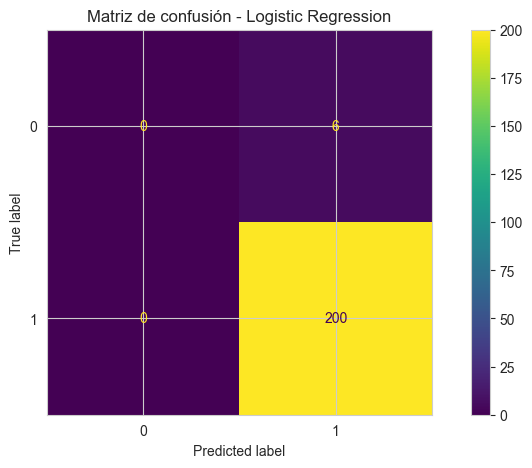

In [14]:

matriz = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz)

disp.plot()

plt.title("Matriz de confusión - Logistic Regression")

plt.show()


# 9. Modelo 2 — Random Forest

In [15]:

pipeline_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        random_state=42,
        n_estimators=100
    ))
])

pipeline_rf.fit(X_train, y_train)


,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:

y_pred_rf = pipeline_rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy Random Forest: {accuracy_rf:.4f}")


Accuracy Random Forest: 1.0000


In [17]:

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00       200

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206



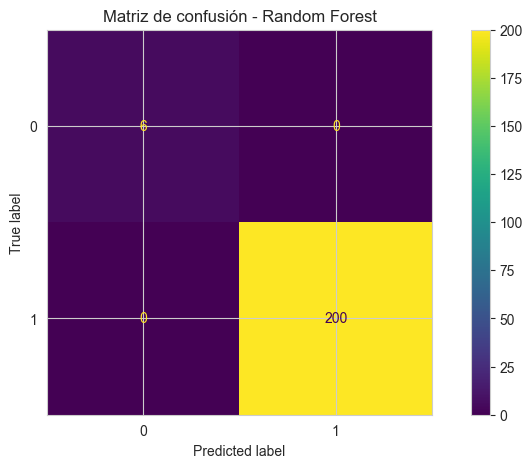

In [18]:

matriz_rf = confusion_matrix(y_test, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(confusion_matrix=matriz_rf)

disp_rf.plot()

plt.title("Matriz de confusión - Random Forest")

plt.show()


# 10. Comparación inicial de modelos

In [19]:

comparacion = pd.DataFrame({
    "Modelo": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_rf
    ]
})

comparacion


,Modelo,Accuracy
0,Logistic Regression,0.970874
1,Random Forest,1.000000



## Conclusiones

- La variable `entrega_tardia` puede abordarse correctamente como un problema de clasificación.
- Las variables logísticas seleccionadas aportan información relevante para el modelo.
- Fue necesario aplicar técnicas de imputación debido a los valores nulos.
- Logistic Regression y Random Forest permiten construir una primera línea base para el problema predictivo.
